# 数据集基本概况

本 notebook 汇总 Kepler 光变数据集的基本统计与可视化，作为后续多元统计分析的基础描述材料。


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path('/Users/Zhuanz/Documents/Dissertation')

DATA_ROOT = PROJECT_ROOT / 'data' / 'kepler'

PALETTE = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#64B5CD', '#DD8452', '#937860']
sns.set_theme(
    context='paper',
    style='whitegrid',
    font_scale=1.1,
    rc={
        'axes.spines.top': False,
        'axes.spines.right': False,
        'grid.linestyle': '--',
        'grid.alpha': 0.3,
    },
)
sns.set_palette(PALETTE)
plt.rcParams['figure.dpi'] = 110


def fd_bins(x, min_bins=12, max_bins=60):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return min_bins
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr == 0:
        return min_bins
    bin_width = 2 * iqr * (len(x) ** (-1 / 3))
    if bin_width <= 0:
        return min_bins
    bins = int(np.ceil((x.max() - x.min()) / bin_width))
    return int(np.clip(bins, min_bins, max_bins))


def no_offset(ax):
    ax.ticklabel_format(style='plain', axis='x')
    ax.get_xaxis().get_major_formatter().set_useOffset(False)


## 数据读取

读取已生成的概况与基线结果 CSV，并在后续统一用 `kic` 做关联。


In [2]:
def read_csv_optional(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    print(f'[WARN] Missing file: {path}')
    return pd.DataFrame()

lc_path = DATA_ROOT / 'lc_overview.csv'
baseline_path = DATA_ROOT / 'baseline_periods_ls_acf.csv'
sample_path = DATA_ROOT / 'mcquillan2014_sample.csv'
catalog_path = DATA_ROOT / 'mcquillan2014_catalog.csv'

df_lc = read_csv_optional(lc_path)
df_base = read_csv_optional(baseline_path)
df_sample = read_csv_optional(sample_path)
df_cat = read_csv_optional(catalog_path)

print('lc_overview:', df_lc.shape)
print('baseline:', df_base.shape)
print('sample:', df_sample.shape)
print('catalog:', df_cat.shape)


lc_overview: (666, 9)
baseline: (500, 11)
sample: (2000, 3)
catalog: (34030, 3)


## 数据覆盖度

统计各子数据的规模与交集，并准备后续的合并数据表。


In [3]:
summary_rows = []

def add_summary(name, df):
    if df.empty:
        summary_rows.append({'dataset': name, 'rows': 0, 'cols': 0})
    else:
        summary_rows.append({'dataset': name, 'rows': len(df), 'cols': len(df.columns)})

add_summary('lc_overview', df_lc)
add_summary('baseline', df_base)
add_summary('sample', df_sample)
add_summary('catalog', df_cat)

summary_df = pd.DataFrame(summary_rows)
summary_df

df_merged = df_lc.copy()
if not df_base.empty and 'kic' in df_base.columns:
    keep_cols = [c for c in ['kic', 'prot_label', 'prot_ls', 'prot_acf', 'prot_gps', 'prot_qpgp'] if c in df_base.columns]
    df_merged = df_merged.merge(df_base[keep_cols], on='kic', how='left')

print('Merged rows:', len(df_merged))


Merged rows: 666


## 基础分布：观测点数、时间基线、采样间隔

这部分描述光变的覆盖范围与采样密度。


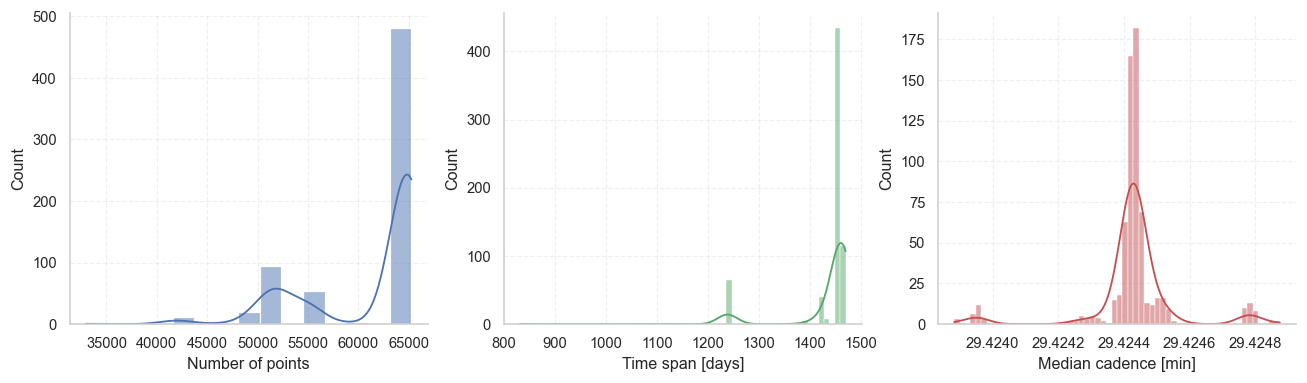

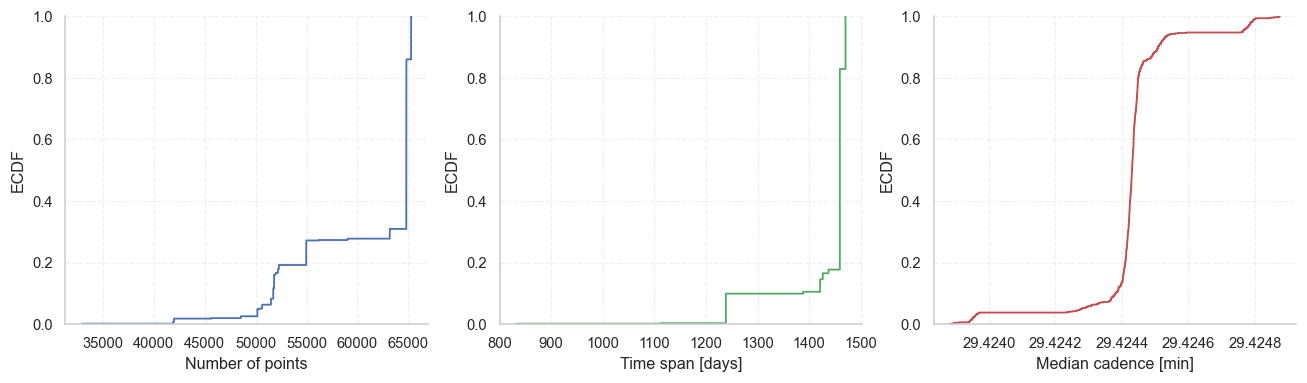

In [4]:
if not df_lc.empty:
    metrics = [
        ('n_points', 'Number of points'),
        ('time_span_days', 'Time span [days]'),
        ('cadence_minutes', 'Median cadence [min]'),
    ]
    colors = [PALETTE[0], PALETTE[1], PALETTE[2]]

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    for ax, (col, label), color in zip(axes, metrics, colors):
        if col in df_lc.columns:
            x = df_lc[col].dropna()
            bins = fd_bins(x)
            sns.histplot(x, bins=bins, kde=True, ax=ax, color=color)
            ax.set_xlabel(label)
            ax.set_ylabel('Count')
            if col == 'cadence_minutes':
                no_offset(ax)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    for ax, (col, label), color in zip(axes, metrics, colors):
        if col in df_lc.columns:
            x = df_lc[col].dropna()
            sns.ecdfplot(x, ax=ax, color=color)
            ax.set_xlabel(label)
            ax.set_ylabel('ECDF')
            if col == 'cadence_minutes':
                no_offset(ax)
    plt.tight_layout()
    plt.show()


## 天体参数分布（Prot / Teff）

比较光变样本与全量目录的分布差异。


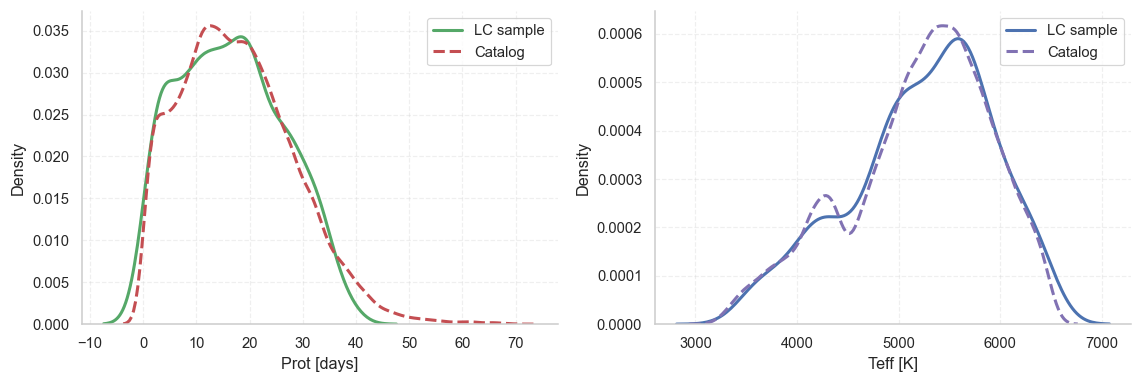

In [5]:
if not df_lc.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))

    if 'prot' in df_lc.columns:
        x = df_lc['prot'].dropna()
        sns.kdeplot(x, ax=axes[0], label='LC sample', color=PALETTE[1], linewidth=2)
        if not df_cat.empty and 'prot' in df_cat.columns:
            sns.kdeplot(
                df_cat['prot'].dropna(),
                ax=axes[0],
                label='Catalog',
                color=PALETTE[2],
                linewidth=2,
                linestyle='--',
            )
        axes[0].set_xlabel('Prot [days]')
        axes[0].set_ylabel('Density')
        axes[0].legend()

    if 'teff' in df_lc.columns:
        x = df_lc['teff'].dropna()
        sns.kdeplot(x, ax=axes[1], label='LC sample', color=PALETTE[0], linewidth=2)
        if not df_cat.empty and 'teff' in df_cat.columns:
            sns.kdeplot(
                df_cat['teff'].dropna(),
                ax=axes[1],
                label='Catalog',
                color=PALETTE[3],
                linewidth=2,
                linestyle='--',
            )
        axes[1].set_xlabel('Teff [K]')
        axes[1].set_ylabel('Density')
        axes[1].legend()

    plt.tight_layout()
    plt.show()


## 光变统计量（幅度与离散度）

通过 `flux_median`、`flux_std` 和变异系数描述光变尺度。


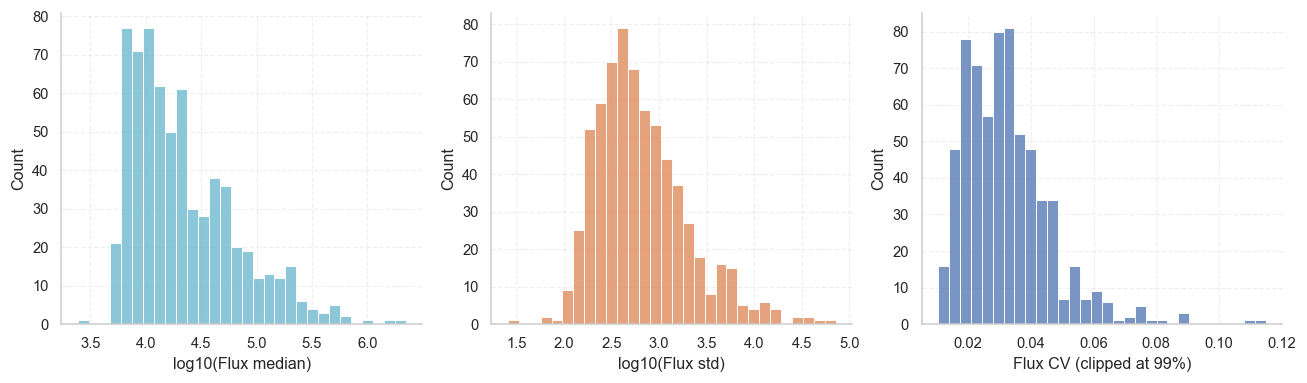

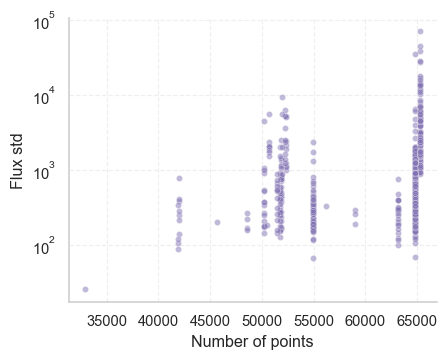

In [6]:
if not df_lc.empty:
    df_lc = df_lc.copy()
    if 'flux_std' in df_lc.columns and 'flux_median' in df_lc.columns:
        df_lc['flux_cv'] = df_lc['flux_std'] / df_lc['flux_median'].abs()

    eps = 1e-8
    if 'flux_median' in df_lc.columns:
        df_lc['log_flux_median'] = np.log10(df_lc['flux_median'].abs().clip(lower=eps))
    if 'flux_std' in df_lc.columns:
        df_lc['log_flux_std'] = np.log10(df_lc['flux_std'].abs().clip(lower=eps))

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    if 'log_flux_median' in df_lc.columns:
        sns.histplot(df_lc['log_flux_median'].dropna(), bins=30, ax=axes[0], color=PALETTE[4])
        axes[0].set_xlabel('log10(Flux median)')
        axes[0].set_ylabel('Count')
    if 'log_flux_std' in df_lc.columns:
        sns.histplot(df_lc['log_flux_std'].dropna(), bins=30, ax=axes[1], color=PALETTE[5])
        axes[1].set_xlabel('log10(Flux std)')
        axes[1].set_ylabel('Count')
    if 'flux_cv' in df_lc.columns:
        x = df_lc['flux_cv'].replace([np.inf, -np.inf], np.nan).dropna()
        if len(x) > 0:
            clip = x.quantile(0.99)
            x = x[x <= clip]
        sns.histplot(x, bins=30, ax=axes[2], color=PALETTE[0])
        axes[2].set_xlabel('Flux CV (clipped at 99%)')
        axes[2].set_ylabel('Count')
    plt.tight_layout()
    plt.show()

    if 'flux_std' in df_lc.columns and 'n_points' in df_lc.columns:
        plt.figure(figsize=(4.2, 3.4))
        sns.scatterplot(data=df_lc, x='n_points', y='flux_std', s=16, alpha=0.5, color=PALETTE[3])
        plt.xlabel('Number of points')
        plt.ylabel('Flux std')
        plt.yscale('log')
        plt.tight_layout()
        plt.show()


## 变量关系：采样、温度与旋转周期

展示与后续多元统计分析相关的变量关系与趋势。


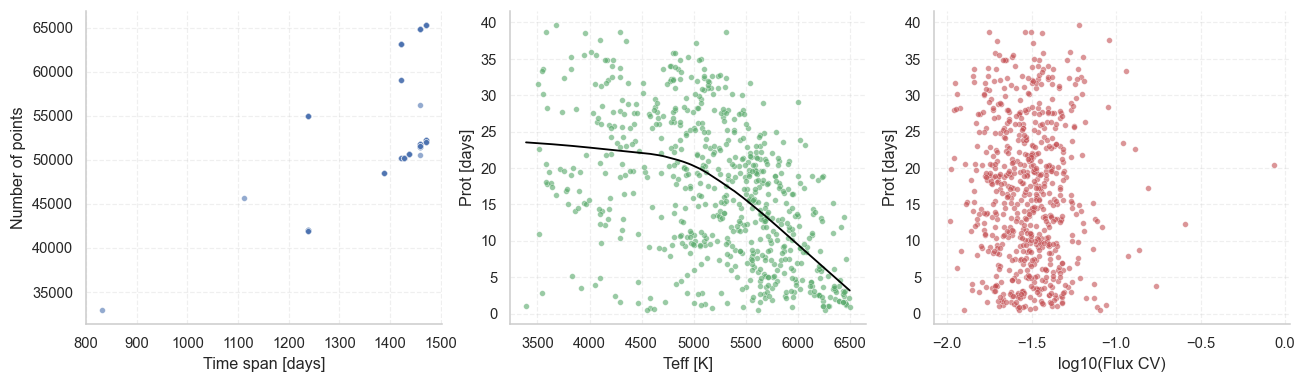

In [7]:
if not df_lc.empty:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))

    if {'time_span_days', 'n_points'}.issubset(df_lc.columns):
        sns.scatterplot(
            data=df_lc,
            x='time_span_days',
            y='n_points',
            s=14,
            alpha=0.6,
            ax=axes[0],
            color=PALETTE[0],
        )
        axes[0].set_xlabel('Time span [days]')
        axes[0].set_ylabel('Number of points')

    if {'teff', 'prot'}.issubset(df_lc.columns):
        sns.scatterplot(
            data=df_lc,
            x='teff',
            y='prot',
            s=14,
            alpha=0.6,
            ax=axes[1],
            color=PALETTE[1],
        )
        sns.regplot(
            data=df_lc,
            x='teff',
            y='prot',
            scatter=False,
            lowess=True,
            ax=axes[1],
            color='black',
            line_kws={'linewidth': 1.2},
        )
        axes[1].set_xlabel('Teff [K]')
        axes[1].set_ylabel('Prot [days]')

    if {'flux_cv', 'prot'}.issubset(df_lc.columns):
        df_tmp = df_lc.copy()
        df_tmp['flux_cv_log'] = np.log10(df_tmp['flux_cv'].clip(lower=1e-6))
        sns.scatterplot(
            data=df_tmp,
            x='flux_cv_log',
            y='prot',
            s=14,
            alpha=0.6,
            ax=axes[2],
            color=PALETTE[2],
        )
        axes[2].set_xlabel('log10(Flux CV)')
        axes[2].set_ylabel('Prot [days]')

    plt.tight_layout()
    plt.show()


## 相关性矩阵与缺失率

用于筛选潜在协变量，并粗看缺失情况。


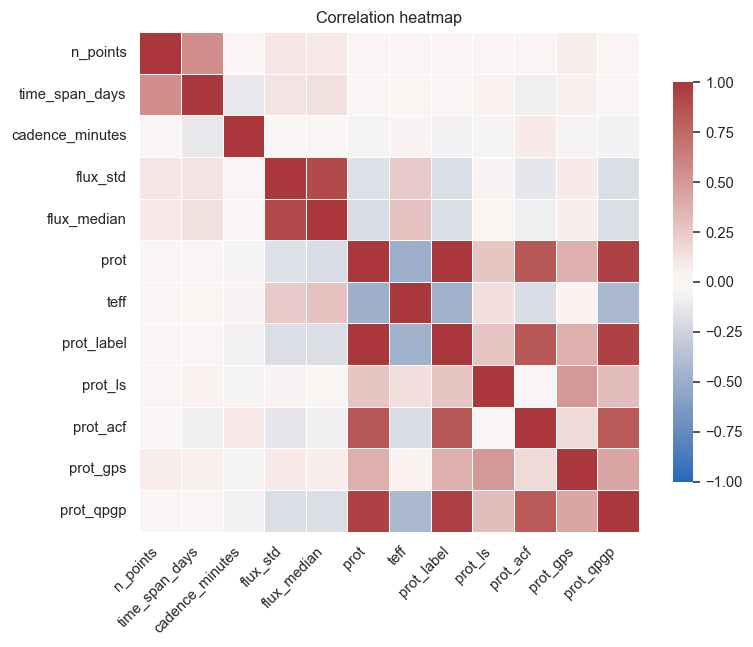

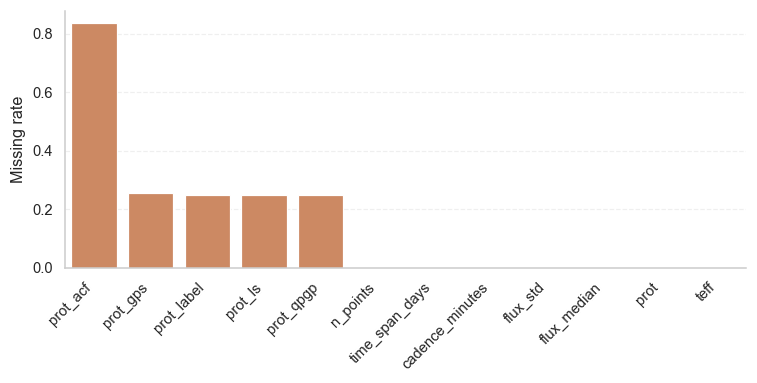

In [8]:
if not df_merged.empty:
    numeric_cols = [
        c for c in [
            'n_points', 'time_span_days', 'cadence_minutes',
            'flux_std', 'flux_median', 'flux_cv', 'prot', 'teff',
            'prot_label', 'prot_ls', 'prot_acf', 'prot_gps', 'prot_qpgp',
        ] if c in df_merged.columns
    ]
    corr = df_merged[numeric_cols].corr()
    plt.figure(figsize=(7.6, 6.0))
    sns.heatmap(
        corr,
        cmap='vlag',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8},
    )
    plt.title('Correlation heatmap')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    miss = df_merged[numeric_cols].isna().mean().sort_values(ascending=False)
    miss_df = miss.reset_index()
    miss_df.columns = ['feature', 'missing_rate']
    plt.figure(figsize=(7.0, 3.6))
    sns.barplot(data=miss_df, x='feature', y='missing_rate', color=PALETTE[5])
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('')
    plt.ylabel('Missing rate')
    plt.tight_layout()
    plt.show()


## 基线方法与标签对照（如果有）

基于 `baseline_periods_ls_acf.csv` 展示预测结果与标签的误差分布。


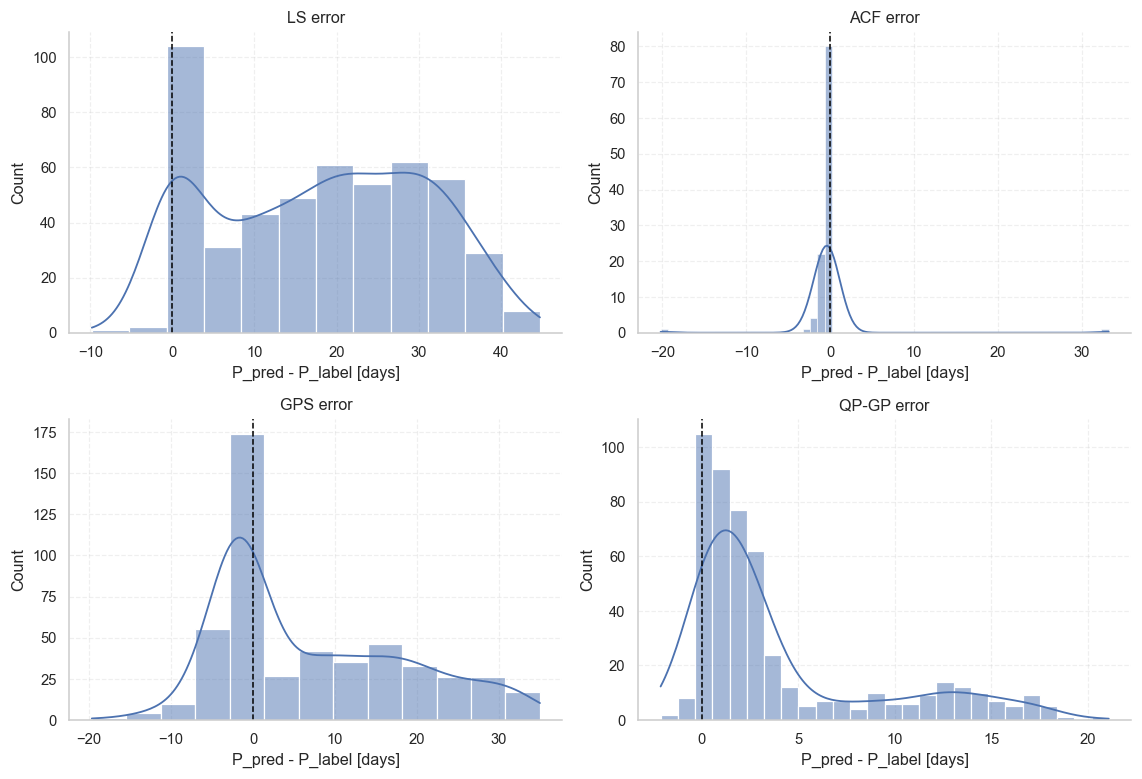

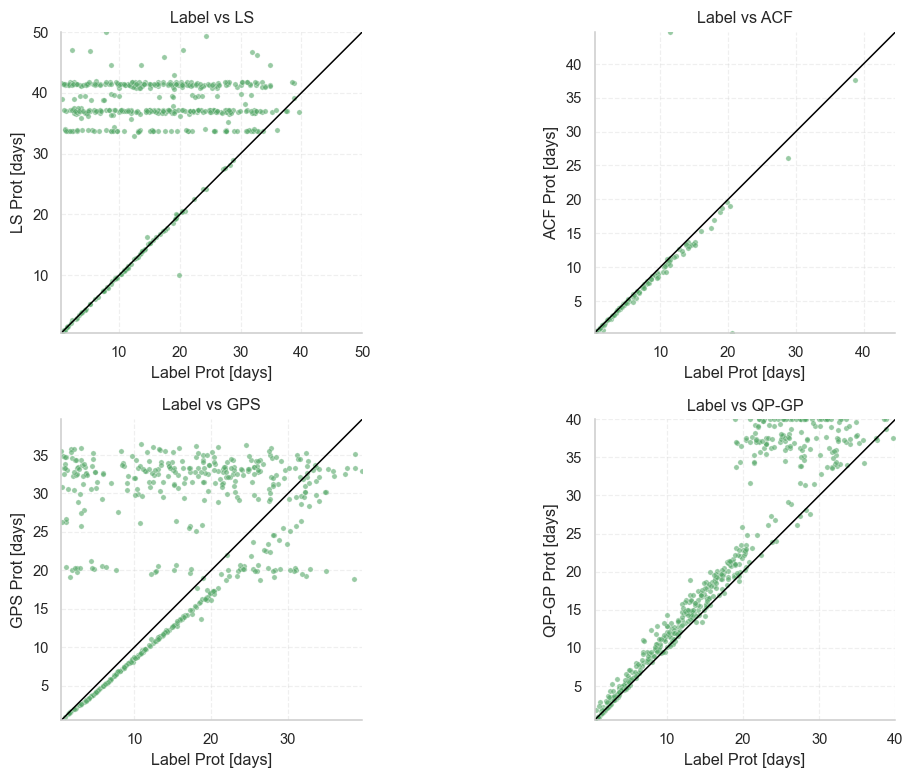

In [9]:
if not df_base.empty and 'prot_label' in df_base.columns:
    df_err = df_base.copy()
    methods = [
        ('LS', 'prot_ls'),
        ('ACF', 'prot_acf'),
        ('GPS', 'prot_gps'),
        ('QP-GP', 'prot_qpgp'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.2))
    axes = axes.ravel()
    for ax, (name, col) in zip(axes, methods):
        if col in df_err.columns:
            err = (df_err[col] - df_err['prot_label']).replace([np.inf, -np.inf], np.nan).dropna()
            bins = fd_bins(err)
            sns.histplot(err, bins=bins, ax=ax, color=PALETTE[0], kde=True)
            ax.axvline(0.0, linestyle='--', linewidth=1.0, color='black')
            ax.set_title(f'{name} error')
            ax.set_xlabel('P_pred - P_label [days]')
            ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.2))
    axes = axes.ravel()
    for ax, (name, col) in zip(axes, methods):
        if col in df_err.columns:
            x = df_err['prot_label']
            y = df_err[col]
            sns.scatterplot(x=x, y=y, s=12, alpha=0.6, ax=ax, color=PALETTE[1])
            lims = [np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])]
            ax.plot(lims, lims, color='black', linewidth=1.0)
            ax.set_xlim(lims)
            ax.set_ylim(lims)
            ax.set_aspect('equal', 'box')
            ax.set_xlabel('Label Prot [days]')
            ax.set_ylabel(f'{name} Prot [days]')
            ax.set_title(f'Label vs {name}')
    plt.tight_layout()
    plt.show()


## 描述性统计表

用于在正文中快速引用的统计摘要（可复制进表格）。


In [13]:
if not df_merged.empty:
    desc = df_merged.describe(percentiles=[0.25, 0.5, 0.75]).T

print(desc)

                 count          mean           std            min  \
kic              666.0  7.947681e+06  2.585059e+06  893647.000000   
n_points         666.0  6.122112e+04  6.094789e+03   32949.000000   
time_span_days   666.0  1.435787e+03  7.103308e+01     831.852809   
cadence_days     666.0  2.043363e-02  9.166210e-08       0.020433   
cadence_minutes  666.0  2.942443e+01  1.319934e-04      29.423883   
flux_median      666.0  5.027270e+04  1.321096e+05    2427.187700   
flux_std         666.0  1.612915e+03  4.598327e+03      25.710583   
prot             666.0  1.654644e+01  9.744689e+00       0.501000   
teff             666.0  5.227673e+03  7.038819e+02    3390.000000   
prot_label       500.0  1.588896e+01  9.807121e+00       0.501000   
prot_ls          500.0  3.388229e+01  1.108510e+01       0.526989   
prot_acf         109.0  7.840893e+00  6.837127e+00       0.286071   
prot_gps         496.0  2.306420e+01  1.108314e+01       0.896321   
prot_qpgp        500.0  1.984653e+